In [1]:
%matplotlib inline
import torch
from IPython import display
from matplotlib import pyplot as plt
import numpy as np
import random

In [2]:
def use_svg_display():
    # 用矢量图显示
    display.set_matplotlib_formats('svg')

def set_figsize(figsize=(3.5, 2.5)):
    use_svg_display()
    # 设置图的尺寸
    plt.rcParams['figure.figsize'] = figsize

# # 在../d2lzh_pytorch里面添加上面两个函数后就可以这样导入
# import sys
# sys.path.append("..")
# from d2lzh_pytorch import *

In [3]:
num_inputs = 2
num_examples = 1000
true_w = [2, -3.4]
true_b = 4.2
features = torch.randn(num_examples, num_inputs, dtype=torch.float32)
print(features)

tensor([[-1.3044, -0.2195],
        [-0.5824, -0.0595],
        [ 0.0920, -0.7337],
        ...,
        [ 1.1662,  1.8390],
        [ 0.4851,  1.5246],
        [-0.2098,  1.6262]])


In [4]:
labels = true_w[0] * features[:, 0] + true_w[1] * features[:, 1] + true_b
print(labels)

tensor([ 2.3375e+00,  3.2374e+00,  6.8787e+00,  2.7603e+00, -4.1157e+00,
         2.1695e+00,  1.1804e+01, -1.7685e+00,  1.5850e+00,  5.6573e+00,
         2.6631e+00,  4.1310e+00,  9.1563e+00, -3.9435e-01,  1.6196e+00,
         4.9105e+00, -2.4352e+00,  7.3731e-01,  4.3350e+00,  6.7572e+00,
         4.0752e+00,  4.0300e+00,  2.8732e+00,  2.4404e+00,  4.0343e+00,
         1.8710e+00,  7.4332e+00,  1.2015e+00,  3.3579e+00,  6.3016e+00,
         6.5470e+00, -3.1116e-01,  2.0998e+00,  5.3713e+00,  1.4702e+00,
         8.7625e+00,  5.7376e+00,  2.4762e+00,  3.9962e-02, -3.4144e+00,
         5.3127e+00,  1.3496e+01,  6.9643e+00, -3.2617e+00,  5.1402e+00,
        -3.0856e-02,  4.0408e+00,  2.3373e+00,  6.6000e+00,  6.8854e-01,
         8.1235e+00,  6.3133e+00,  9.5835e+00,  3.7547e+00, -3.2951e+00,
         2.6399e+00, -1.4283e+00,  2.4364e+00, -1.1772e+00,  3.3796e+00,
         1.3796e+01,  1.5385e+00,  3.3833e+00,  4.4460e+00,  3.9881e+00,
         6.3470e+00,  2.6088e+00,  3.4483e+00,  5.9

C:\Users\dongz\AppData\Local\Temp\ipykernel_2264\4277834102.py:3: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


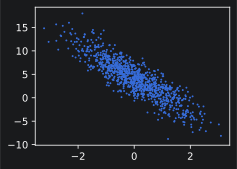

In [5]:
set_figsize()
plt.scatter(features[:, 1].numpy(), labels.numpy(), 1);

In [6]:
## 添加噪声, 模拟真实数据
labels += torch.tensor(np.random.normal(0, 0.01, size=labels.size()), dtype=torch.float32)
print(labels)

tensor([ 2.3153e+00,  3.2513e+00,  6.8794e+00,  2.7518e+00, -4.1155e+00,
         2.1692e+00,  1.1817e+01, -1.7659e+00,  1.6013e+00,  5.6483e+00,
         2.6780e+00,  4.1330e+00,  9.1629e+00, -3.8432e-01,  1.6165e+00,
         4.9276e+00, -2.4357e+00,  7.3736e-01,  4.3305e+00,  6.7390e+00,
         4.0762e+00,  4.0248e+00,  2.8756e+00,  2.4425e+00,  4.0437e+00,
         1.8703e+00,  7.4179e+00,  1.2087e+00,  3.3429e+00,  6.2829e+00,
         6.5364e+00, -3.0443e-01,  2.1002e+00,  5.3622e+00,  1.4613e+00,
         8.7540e+00,  5.7310e+00,  2.5010e+00,  4.8368e-02, -3.3846e+00,
         5.3211e+00,  1.3501e+01,  6.9643e+00, -3.2599e+00,  5.1557e+00,
        -3.5415e-02,  4.0160e+00,  2.3547e+00,  6.6064e+00,  6.8964e-01,
         8.1200e+00,  6.3134e+00,  9.5948e+00,  3.7558e+00, -3.3130e+00,
         2.6336e+00, -1.4370e+00,  2.4418e+00, -1.1863e+00,  3.3619e+00,
         1.3777e+01,  1.5357e+00,  3.3676e+00,  4.4443e+00,  3.9781e+00,
         6.3295e+00,  2.6236e+00,  3.4585e+00,  5.9

C:\Users\dongz\AppData\Local\Temp\ipykernel_2264\4277834102.py:3: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


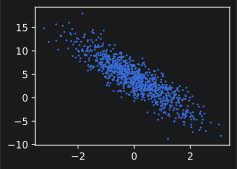

In [7]:

set_figsize()
plt.scatter(features[:, 1].numpy(), labels.numpy(), 1);


In [8]:
# 本函数已保存在d2lzh包中方便以后使用
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    random.shuffle(indices)  # 样本的读取顺序是随机的
    for i in range(0, num_examples, batch_size):
        j = torch.LongTensor(indices[i: min(i + batch_size, num_examples)]) # 最后一次可能不足一个batch
        yield  features.index_select(0, j), labels.index_select(0, j)


In [9]:
batch_size = 10

for X, y in data_iter(batch_size, features, labels):
    print(X, y)
    break


tensor([[-0.5359,  2.0804],
        [ 0.6194,  1.0167],
        [ 1.0888,  1.2662],
        [ 0.3365,  0.0622],
        [-2.5713,  0.9928],
        [ 0.6747, -1.8903],
        [-0.7907,  1.0105],
        [ 1.0868, -1.0699],
        [-0.4593,  0.5080],
        [ 0.5176, -0.4761]]) tensor([-3.9353,  1.9724,  2.0770,  4.6636, -4.3212, 11.9627, -0.8182, 10.0161,
         1.5733,  6.8463])


In [18]:
w = torch.tensor(np.random.normal(0, 0.01, (num_inputs, 1)), dtype=torch.float32)
b = torch.zeros(1, dtype=torch.float32)


In [19]:
w.requires_grad_(requires_grad=True)
b.requires_grad_(requires_grad=True)
print(w, '\n', b)

tensor([[ 0.0078],
        [-0.0101]], requires_grad=True) 
 tensor([0.], requires_grad=True)


In [20]:
def linreg(X, w, b):  # 本函数已保存在d2lzh_pytorch包中方便以后使用
    return torch.mm(X, w) + b



In [21]:
def squared_loss(y_hat, y):  # 本函数已保存在d2lzh_pytorch包中方便以后使用
    # 注意这里返回的是向量, 另外, pytorch里的MSELoss并没有除以 2
    return (y_hat - y.view(y_hat.size())) ** 2 / 2


In [22]:
def sgd(params, lr):  # 本函数已保存在d2lzh_pytorch包中方便以后使用
    for param in params:
        param.data -= lr * param.grad # 注意这里更改param时用的param.data

In [23]:
for X, y in data_iter(batch_size, features, labels):
    print('X: \n',X, '\ny:\n', y)
    print('loss:\n', squared_loss(linreg(X, w, b), y))
    break

X: 
 tensor([[ 0.0395,  0.0079],
        [ 0.2492,  0.7937],
        [-1.8686,  1.2126],
        [ 0.0115,  0.1227],
        [ 1.7468, -0.5039],
        [-0.5348,  0.4352],
        [-0.0419, -1.8476],
        [-1.7682,  1.0847],
        [ 0.7011, -2.4879],
        [ 0.0659, -0.6084]]) 
y:
 tensor([ 4.2506,  1.9947, -3.6488,  3.8059,  9.4043,  1.6547, 10.3872, -3.0106,
        14.0474,  6.3942])
loss:
 tensor([[ 9.0327],
        [ 2.0016],
        [ 6.5592],
        [ 7.2470],
        [44.0442],
        [ 1.3833],
        [53.7567],
        [ 4.4576],
        [98.2345],
        [20.4002]], grad_fn=<DivBackward0>)


In [24]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss

for epoch in range(num_epochs):  # 训练模型一共需要num_epochs个迭代周期
    # 在每一个迭代周期中，会使用训练数据集中所有样本一次（假设样本数能够被批量大小整除）。X
    # 和y分别是小批量样本的特征和标签
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y).mean()  # l是有关小批量X和y的损失
        l.backward()  # 小批量的损失对模型参数求梯度
        sgd([w, b], lr)  # 使用小批量随机梯度下降迭代模型参数

        # 不要忘了梯度清零
        w.grad.data.zero_()
        b.grad.data.zero_()
    train_l = loss(net(features, w, b), labels)
    print('epoch %d, loss %f' % (epoch + 1, train_l.mean().item()))


epoch 1, loss 0.039225
epoch 2, loss 0.000149
epoch 3, loss 0.000049


In [17]:
print(true_w, '\n', w)
print(true_b, '\n', b)


[2, -3.4] 
 tensor([[ 1.9993],
        [-3.3991]], requires_grad=True)
4.2 
 tensor([4.1990], requires_grad=True)
